# 3. Перестроение модели на новых данных

Загружаем сохранённую модель и пайплайн из бук 2, берём новые данные, переобучаем пайплайн и GLM.

**Куда пишутся результаты:**
- `export_model_results` → `model_analysis/{dataset_name}/` (Excel, HTML, графики)
- `savem` → `models/{dataset_name}/` (модель, пайплайн, metadata, данные)

In [ ]:
import sys
from pathlib import Path
import pandas as pd
import joblib
import copy
from sklearn.model_selection import train_test_split
from ipyfilechooser import FileChooser
from IPython.display import display

# Путь к deps/repo_glm для axiolyze (если пакет не установлен через pip install -e)
_glm_path = Path('../../deps/repo_glm').resolve()
if str(_glm_path) not in sys.path:
    sys.path.insert(0, str(_glm_path))

# Legacy-скрипты: support, model_io, io_utils, glm_analysis
_legacy_path = Path('../../deps/repo_glm/axiolyze/legacy').resolve()
if str(_legacy_path) not in sys.path:
    sys.path.insert(0, str(_legacy_path))

# Трансформеры — из axiolyze
from axiolyze.transformers import GLMSmartDataFilterTransformation

# support, model_io, glm_analysis — из axiolyze/legacy/ (добавлено в sys.path выше)
from support import selection_rule_column, check_design_matrix_stability
from model_io import loadm, savem
from glm_analysis import (
    create_advanced_glm_formula,
    fit_glm_model,
    extract_categorical_levels,
    compute_representative_levels,
    apply_categorical_mapping,
    analyze_glm_model,
    display_metrics,
    export_model_results,
)


def read_df_from_sql(query, sql_server_name=None, db_name=None, **kwargs):
    """Загрузка из SQL: vsk_omtl или fallback на sqlalchemy."""
    try:
        from vsk_omtl import read_df_from_sql as custom_read_sql
        return custom_read_sql(query=query, sql_server_name=sql_server_name, db_name=db_name, **kwargs)
    except (ImportError, NameError):
        try:
            from sqlalchemy import create_engine
            cs = kwargs.pop('connection_string', 'sqlite:///:memory:')
            if sql_server_name and db_name:
                cs = f"mssql+pyodbc://@{sql_server_name}/{db_name}?driver=ODBC+Driver+17+for+SQL+Server&trusted_connection=yes"
            engine = create_engine(cs)
            try:
                return pd.read_sql(query, con=engine, **kwargs)
            finally:
                engine.dispose()
        except Exception as e:
            raise ValueError(f"Не удалось загрузить данные из SQL: {e}")


def extract_schema_from_pipeline(pipeline):
    """Извлекает data_schema из первого шага (SmartDataFilter)."""
    for step_name, transformer in pipeline.steps:
        if isinstance(transformer, GLMSmartDataFilterTransformation):
            return transformer.get_data_schema()
    return {}

## Выбор модели и загрузка

In [2]:
dataset_name = 'research_transformers'
dataset_dir = Path('models') / dataset_name
if not dataset_dir.exists():
    raise FileNotFoundError(f"Папка датасета не найдена: {dataset_dir}")

available_hashes = set()
for f in dataset_dir.iterdir():
    if f.name.count('_') >= 1:
        available_hashes.add(f.name.split('_')[0])
available_hashes = list(available_hashes)
selected_hashes = selection_rule_column(available_hashes)

In [3]:
selected_hash = selected_hashes[0]

model_dict = loadm(dataset_name, selected_hash)

pipeline_joblib_path = dataset_dir / f"{selected_hash}_pipeline.joblib"
if not pipeline_joblib_path.exists():
    raise FileNotFoundError(
        f"Pipeline не найден: {pipeline_joblib_path}. "
        "Запустите 2_research_transformers_clean и savem."
    )
pipeline = joblib.load(pipeline_joblib_path)

data_schema = extract_schema_from_pipeline(pipeline)
exposure_name = data_schema.get('exposure_column', 'exposure')
exposure_translated = model_dict['name_mapping'].get(exposure_name, exposure_name)
target_original = data_schema.get('target_column', 'default_target')
target_translated = model_dict['formula'].split(' ~ ')[0].strip()
old_formula = model_dict['model_info']['formula']
old_family = model_dict['model_info']['family']
old_link = model_dict['model_info']['link']
old_numerics = list(model_dict.get('numerical_params', {}).keys())
old_categoricals = list(model_dict.get('categorical_params', {}).keys())
contrast_method = 'Sum'

## Загрузка новых данных

In [4]:
fc_data = FileChooser(
    path='.', filename='', filter_pattern=('*.csv', '*.feather'),
    title='ВАРИАНТ 1: Выберите файл данных (CSV или Feather)'
)
display(fc_data)

fc_sql = FileChooser(
    path='.', filename='', filter_pattern=('*.sql',),
    title='ВАРИАНТ 2: Выберите файл с SQL запросом'
)
display(fc_sql)

FileChooser(path='C:\Users\puls\PycharmProjects\glm', filename='', title='ВАРИАНТ 1: Выберите файл данных (CSV…

FileChooser(path='C:\Users\puls\PycharmProjects\glm', filename='', title='ВАРИАНТ 2: Выберите файл с SQL запро…

In [5]:
if fc_data.selected:
    fp = Path(fc_data.selected)
    if fp.suffix == '.csv':
        df = pd.read_csv(fp)
    elif fp.suffix == '.feather':
        df = pd.read_feather(fp)
    else:
        df = pd.read_csv(fp)
    print(f"Загружено из файла: {fp}")
elif fc_sql.selected:
    with open(fc_sql.selected, 'r', encoding='utf-8') as f:
        query = f.read()
    df = read_df_from_sql(query=query, sql_server_name=None, db_name=None, n_jobs=1, debug_sql=False)
    print(f"Загружено из SQL: {fc_sql.selected}")
else:
    print("Не выбран источник данных. Выберите файл или SQL запрос выше.")
    df = None

if df is not None:
    print(f"Загружено строк: {df.shape[0]}, колонок: {df.shape[1]}")
    X, y = df.drop(columns=[target_original]), df[target_original]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    df_train = pd.concat([X_train, y_train], axis=1)
    df_test = pd.concat([X_test, y_test], axis=1)

Загружено из файла: C:\Users\puls\PycharmProjects\glm\unbalanced_dataset_train.csv
Загружено строк: 10000, колонок: 6


## Переобучение пайплайна и модели

In [6]:
new_pipeline = copy.deepcopy(pipeline)
df_train_transformed = new_pipeline.fit_transform(df_train)
df_test_transformed = new_pipeline.transform(df_test)
df_train_transformed = df_train_transformed.dropna(subset=[target_translated])

In [7]:
unexpected = new_pipeline.steps[-1][1].get_unexpected_features()
new_categorical_levels = extract_categorical_levels(df_train_transformed, old_categoricals)

formula, numerical_params, categorical_params = create_advanced_glm_formula(
    numerics=old_numerics,
    categoricals=old_categoricals,
    target=target_translated,
    df=df_train_transformed,
    categorical_levels=new_categorical_levels,
    unexpected_columns=unexpected,
    center_numerics=True,
    standardize_numerics=True,
    contrast_method=contrast_method,
)

representative_levels = compute_representative_levels(
    df_train_transformed, categorical_params, exposure_translated
)
df_for_fit = apply_categorical_mapping(
    df_train_transformed.copy(), categorical_params, representative_levels
)

# Заполнение пропусков (как в бук 2)
for c in categorical_params:
    if c in df_for_fit.columns and c in representative_levels:
        fill_val = representative_levels[c] if representative_levels[c] in categorical_params[c] else categorical_params[c][0]
        df_for_fit[c] = df_for_fit[c].fillna(fill_val)
numerics = list(numerical_params.keys())
for c in numerics:
    if c in df_for_fit.columns:
        df_for_fit[c] = df_for_fit[c].fillna(df_for_fit[c].mean())

# Диагностика: число обусловленности (κ < 100 — хорошо)
check_design_matrix_stability(df_for_fit, formula)

new_model_dict = fit_glm_model(
    df=df_for_fit,
    formula=formula,
    numerical_params=numerical_params,
    categorical_params=categorical_params,
    family=old_family,
    link=old_link,
    exposure_column=exposure_translated,
)

Condition number design matrix: 1.50e+01
Численная устойчивость в норме.
=== ДИАГНОСТИКА МЕТРИК ===
y_true: min=86351.0000, max=296596.0000, mean=148833.3516, std=31894.9354
y_pred: min=114693.5124, max=230363.4315, mean=148833.3516, std=27956.5150
Корреляция y_true vs y_pred: 0.8767


C:\Users\puls\PycharmProjects\glm\glm_analysis.py:2630: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  level_stats = df.groupby(col)[exposure_column].sum()
C:\Users\puls\PycharmProjects\glm\.venv\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:308: DomainWarning: The Identity link function does not respect the domain of the Poisson family.
  warnings.warn((f"The {type(family.link).__name__} link function "
C:\Users\puls\PycharmProjects\glm\glm_analysis.py:2630: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  level_stats = df.groupby(col)[exposure_column].sum()


In [8]:
df_train_transformed

,Unnamed_0,Marka,Strakhovaia_summa,Kolichestvo_dnei_ot_sobytiia_do_uregulirovaniia,Otsenka_ubytka,new_exposure
9254,9254,Киа,3.180208e+06,15.0,170661,1.0
1561,1561,Киа,3.158605e+06,6.0,134191,1.0
1670,1670,Лада Самара,5.178867e+05,4.0,126949,1.0
6087,6087,Киа,2.026844e+06,46.0,150502,1.0
6669,6669,Лада Самара,4.647119e+05,34.0,147273,1.0
...,...,...,...,...,...,...
5734,5734,Жигули,4.336247e+05,18.0,132497,1.0
5191,5191,Лада Самара,5.555028e+05,0.0,124385,1.0
5390,5390,Жигули,4.033053e+05,17.0,125175,1.0
860,860,Lada,1.220633e+06,42.0,149603,1.0


## Анализ и сохранение

## Экспорт результатов (Excel, HTML, графики)

In [9]:
old_analysis_results = analyze_glm_model(model_dict, pipeline)
new_analysis_results = analyze_glm_model(new_model_dict, new_pipeline)
display_metrics(new_analysis_results, old_analysis_results=old_analysis_results)

,Метрика,Текущее значение,Предыдущее значение,Изменение,Описание
0,MAE,12030.8117,12030.8117,+0.0000,Средняя абсолютная ошибка. Робастна к выбросам...
1,MSE,235320449.7454,235320449.7447,+0.0006,Средняя квадратичная ошибка. Чувствительна к в...
2,RMSE,15340.1581,15340.1581,+0.0000,"Корень из MSE. В единицах целевой переменной, ..."
3,R²,0.7687,0.7687,-0.0000,Классический R² = 1 - SS_res/SS_tot. Доля объя...
4,AIC,12296759.2946,12296759.2946,-0.0000,AIC = -2×LL + 2×k. Штрафует за сложность модел...
5,BIC,12296815.1922,12296815.1922,-0.0000,BIC = -2×LL + k×ln(n). Сильнее штрафует сложно...
6,McFadden R²,0.7616,0.7616,+0.0000,R² МакФаддена = 1 - LL_model/LL_null. Для GLM ...
7,Deviance R²,0.7616,0.7616,+0.0000,R² девиации = 1 - D_model/D_null. Эквивалентен...
8,Nagelkerke R²,1.0000,1.0000,+0.0000,R² Нагелькерке = R² Кокса-Снелла нормализованн...
9,Gini (ordered Lorenz),0.8338,0.8338,+0.0000,Gini index (ordered Lorenz). G_pred/G_true: ка...


🔍 Определен тип модели: frequency
📊 Графики для моделей частоты (Poisson, NegativeBinomial с экспозицией)
✅ Основные графики: crunched_residuals, calibration_plot, qq_plot
⏭️  Пропущены неинформативные: predictions_vs_actual, residuals_scatter
💡 Для построения всех графиков используйте force_all_plots=True


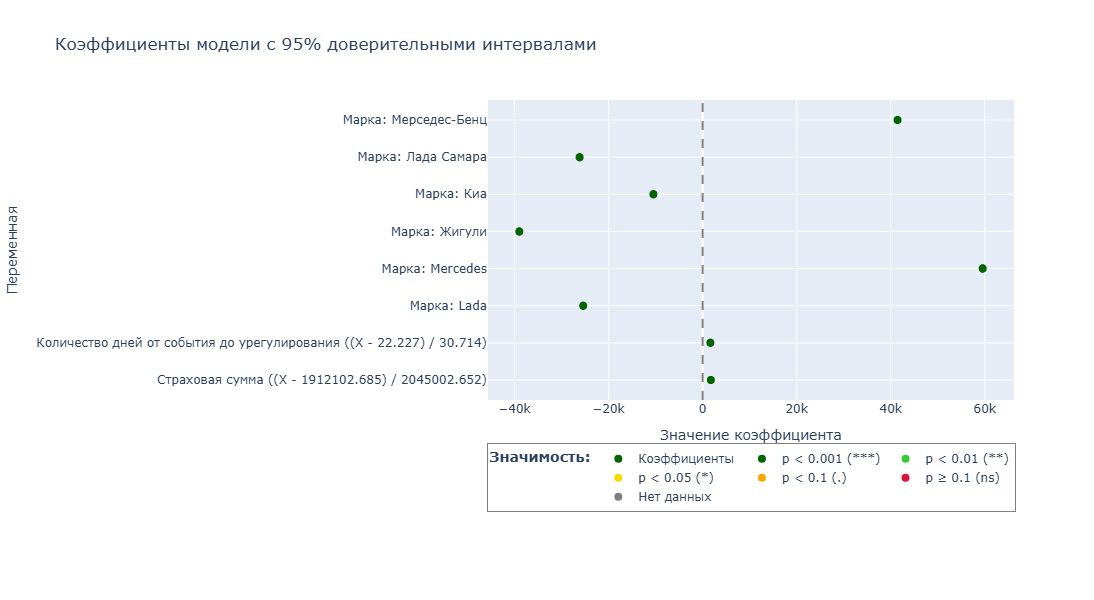

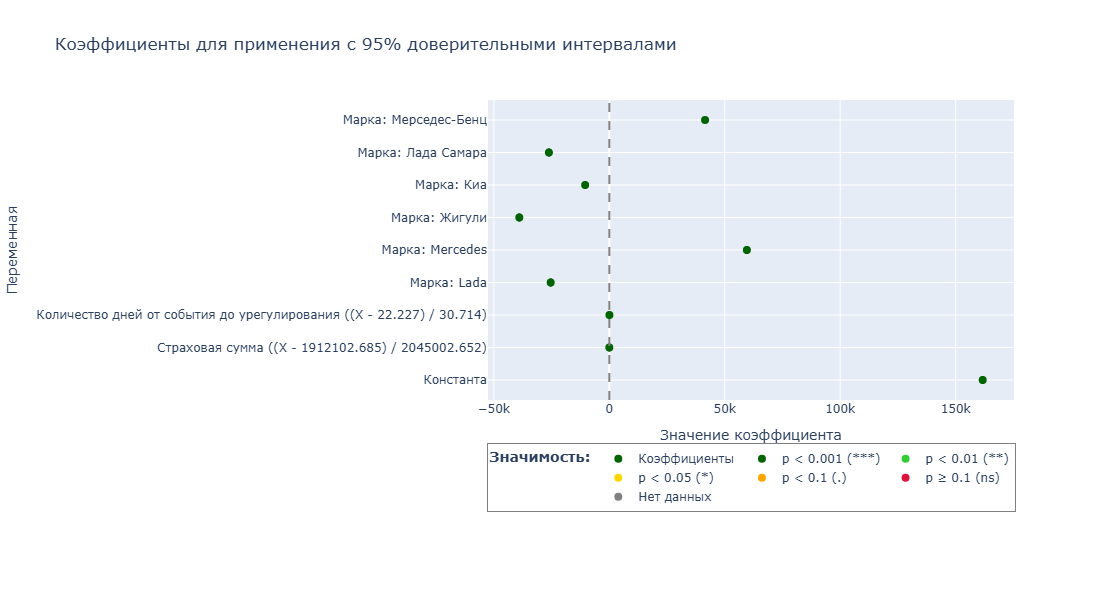

📈 Используется 1000 точек для графиков из 8000 общих
🔬 Семейство распределения: poisson
📊 Тип остатков по умолчанию: deviance


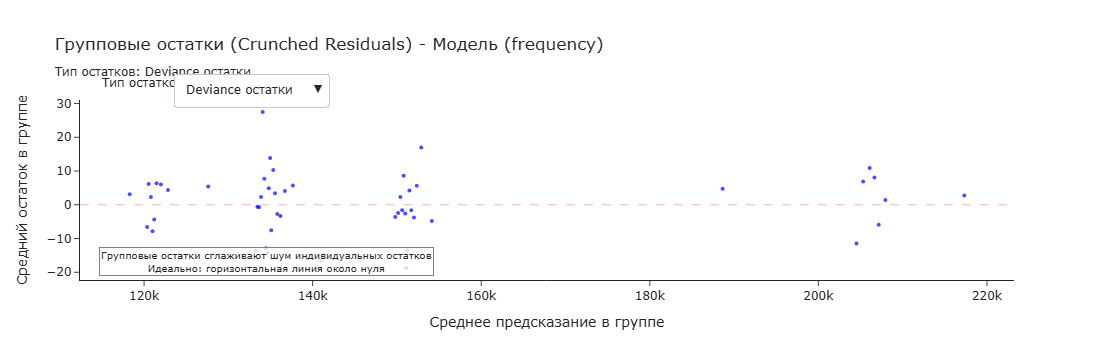

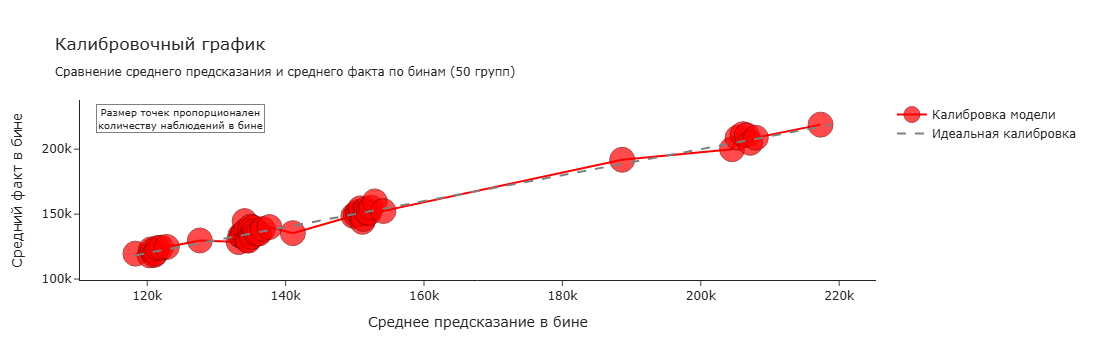

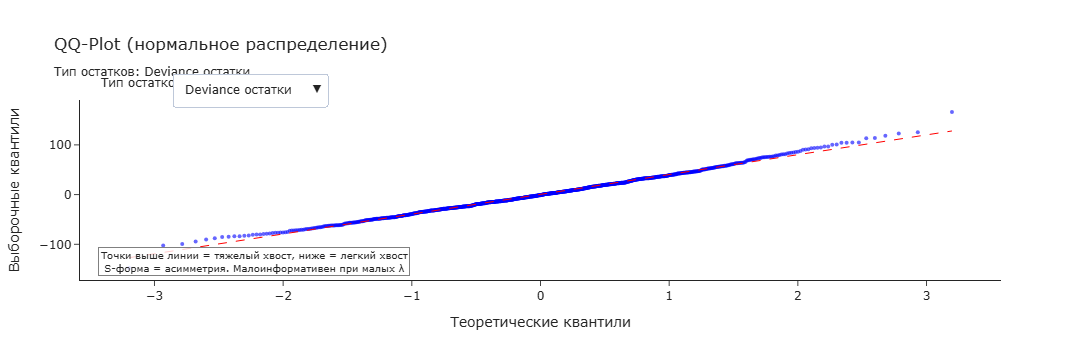

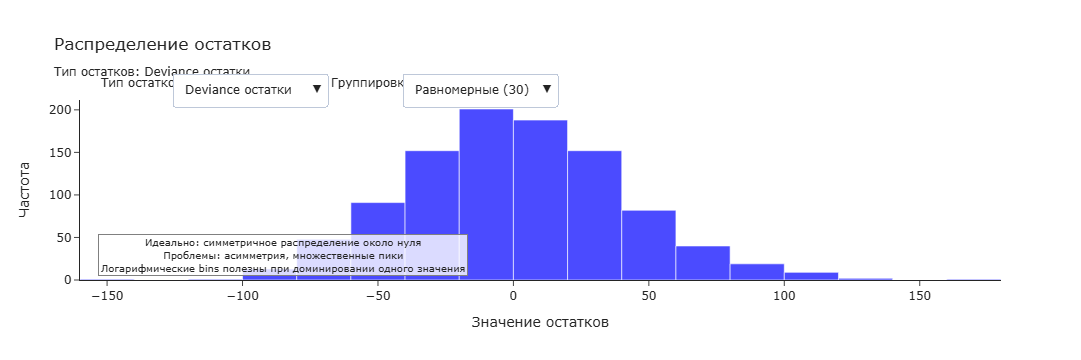

📑 Индекс графиков: model_analysis\research_transformers\b8b0d9136e9dd73810c41881cbb82553_index.html
✅ Анализ завершен! Результаты сохранены в: model_analysis\research_transformers
🎯 Построены графики, оптимизированные для модели frequency


In [10]:
output_dir = Path('model_analysis') / dataset_name
export_model_results(
    new_analysis_results,
    output_dir=str(output_dir),
    show_plots=True,
    model_type_hint='auto',
)

In [11]:
feature_types = {
    'numeric': list(numerical_params.keys()),
    'categorical': list(categorical_params.keys()),
    'ordered': [],
}
savem(
    name_mapping=new_pipeline.steps[-1][1].get_column_mapping(),
    dataset_name=dataset_name,
    pipeline=new_pipeline,
    df=df_for_fit,
    analysis_results=new_analysis_results,
    model_dict=new_model_dict,
    file_extension='.csv',
    feature_types=feature_types,
)

✅ Модель сохранена: models\research_transformers\b8b0d9136e9dd73810c41881cbb82553_model.pkl
✅ Метаданные сохранены: models\research_transformers\b8b0d9136e9dd73810c41881cbb82553_metadata.yaml
Сохранены данные с хэшем b8b0d9136e9dd73810c41881cbb82553 в models\research_transformers\b8b0d9136e9dd73810c41881cbb82553_data.csv
✅ Данные автоматически сохранены в формате .csv
Сохранен конфиг пайплайна в models\research_transformers\b8b0d9136e9dd73810c41881cbb82553_pipeline.yaml
✅ Pipeline YAML (конфиг) автоматически сохранен
Сохранен пайплайн в models\research_transformers\b8b0d9136e9dd73810c41881cbb82553_pipeline.joblib
🎯 Полный эксперимент сохранен с hash: b8b0d9136e9dd73810c41881cbb82553


'b8b0d9136e9dd73810c41881cbb82553'